In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up folders
data_path = Path("../data/cleaned_telco_churn.csv")
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)


# Load cleaned data
df = pd.read_csv(data_path)

# Set chart style
sns.set_theme(style="whitegrid")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()

Dataset loaded successfully!
Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [34]:
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nOverall churn rate:")
print(round(df["Churn"].mean() * 100, 2), "%")

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

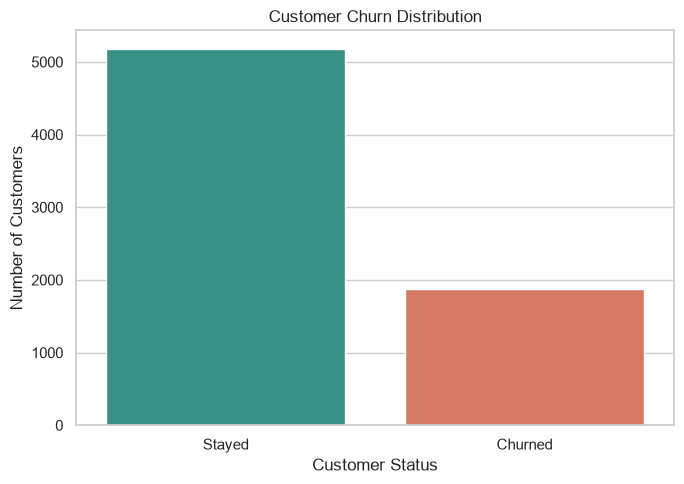

Churn percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [45]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette={0: "#2A9D8F", 1: "#E76F51"},
    legend=False
)

ax.set_xticks([0, 1], ["Stayed", "Churned"])
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(output_dir / "01_churn_distribution.png", dpi=150)
plt.show()

print("Churn percentages:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

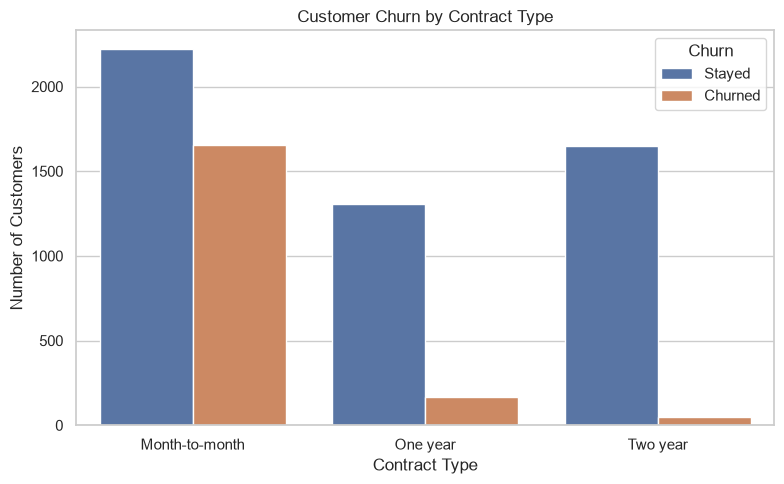

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.tight_layout()
plt.savefig("../outputs/02_churn_by_contract.png", dpi=300)
plt.show()

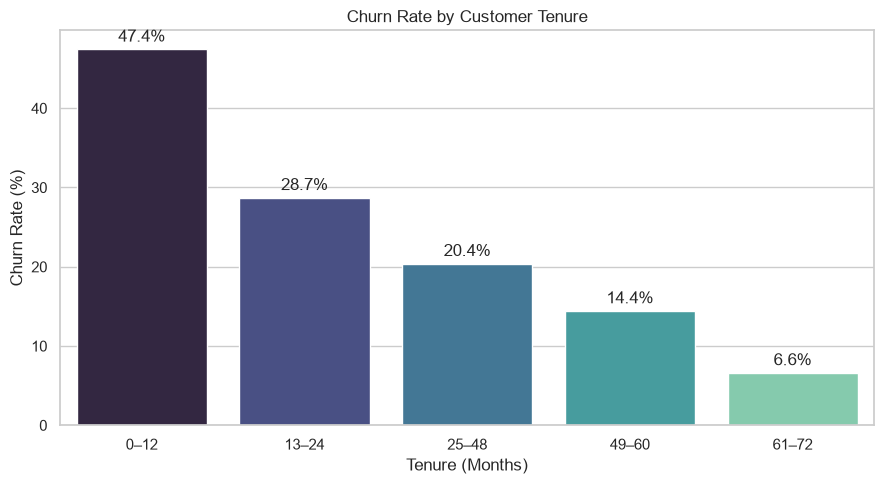

TenureGroup
0–12     47.44
13–24    28.71
25–48    20.39
49–60    14.42
61–72     6.61
Name: Churn, dtype: float64


In [47]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=["0–12", "13–24", "25–48", "49–60", "61–72"]
)

tenure_churn = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=tenure_churn.index.astype(str),
    y=tenure_churn.values,
    hue=tenure_churn.index.astype(str),
    palette="mako",
    legend=False
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig(output_dir / "03_churn_by_tenure.png", dpi=150)
plt.show()

print(tenure_churn.round(2))

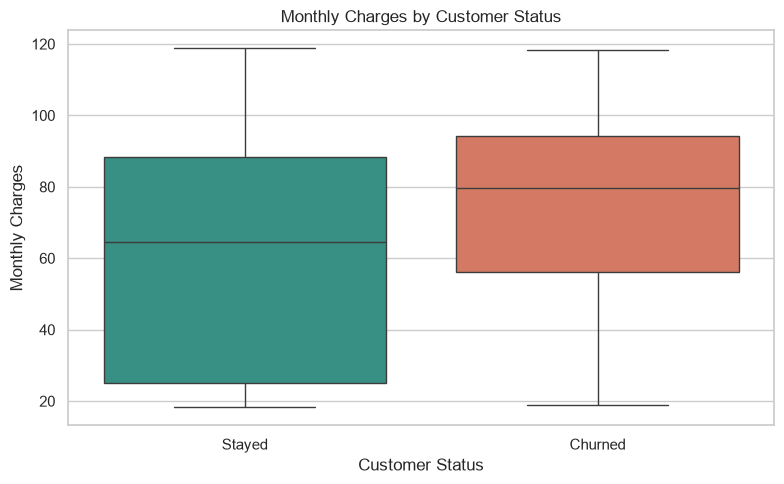

        mean  median
Churn               
0      61.27   64.43
1      74.44   79.65


In [39]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette={0: "#2A9D8F", 1: "#E76F51"},
    legend=False
)

ax.set_xticks([0, 1], ["Stayed", "Churned"])
plt.title("Monthly Charges by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.savefig(output_dir / "04_monthly_charges_by_churn.png", dpi=150)
plt.show()

print(
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["mean", "median"])
    .round(2)
)

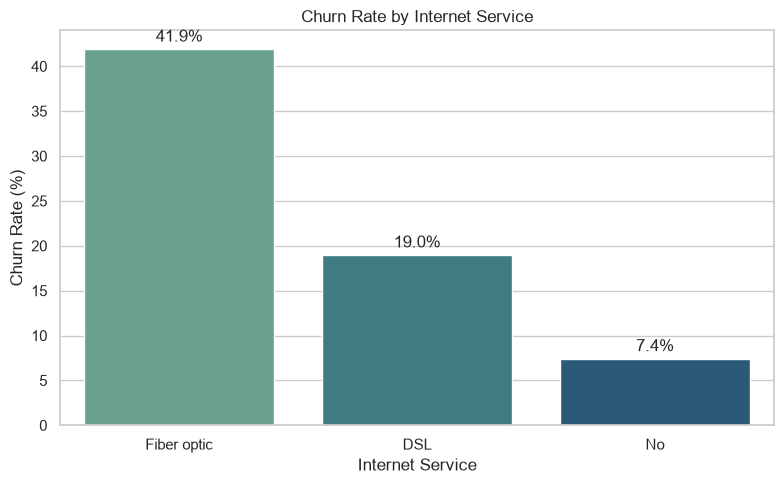

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


In [40]:
internet_churn = (
    df.groupby("InternetService", observed=True)["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values,
    hue=internet_churn.index,
    palette="crest",
    legend=False
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig(output_dir / "05_churn_by_internet_service.png", dpi=150)
plt.show()

print(internet_churn.round(2))

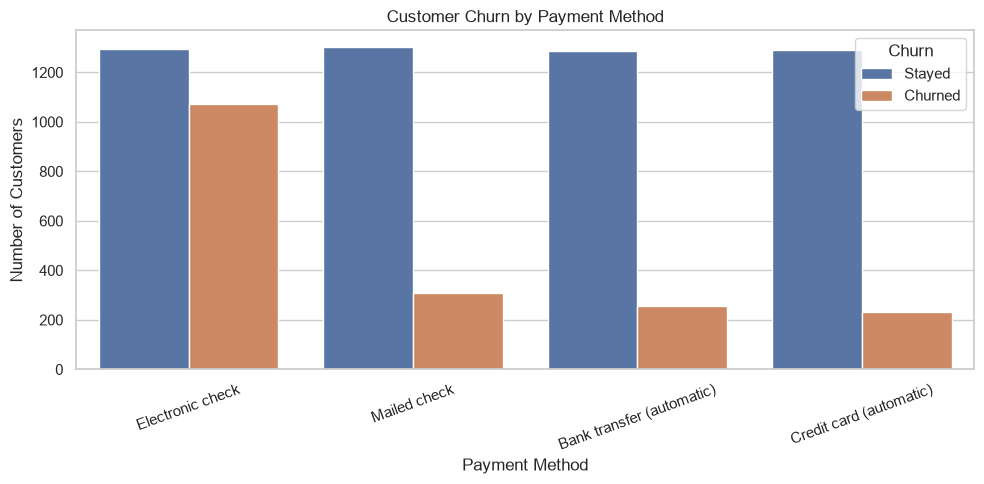

In [52]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.tight_layout()
plt.savefig("../outputs/06_churn_by_payment_method.png", dpi=300)
plt.show()

## Churn Rate Analysis

Count-based charts show the number of churned customers, while churn rates allow comparison between different customer groups.

In [43]:
def churn_rate_by(column):
    result = (
        df.groupby(column)["Churn"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )
    
    result["churn_rate"] = result["mean"] * 100
    result = result.drop(columns=["mean"])
    
    return result.sort_values("churn_rate", ascending=False)

In [20]:
churn_rate_by("Contract")

,Contract,count,sum,churn_rate
0,Month-to-month,3875,1655,42.709677
1,One year,1473,166,11.269518
2,Two year,1695,48,2.831858


In [21]:
churn_rate_by("InternetService")

,InternetService,count,sum,churn_rate
1,Fiber optic,3096,1297,41.892765
0,DSL,2421,459,18.959108
2,No,1526,113,7.404980


In [22]:
churn_rate_by("PaymentMethod")

,PaymentMethod,count,sum,churn_rate
2,Electronic check,2365,1071,45.285412
3,Mailed check,1612,308,19.106700
0,Bank transfer (automatic),1544,258,16.709845
1,Credit card (automatic),1522,232,15.243101


## Key EDA Insights

1. Month-to-month customers show substantially higher churn than customers with one-year or two-year contracts, making contract type one of the strongest visible churn indicators.
2. Customers with shorter tenure show higher churn concentration, suggesting that the early customer lifecycle is an important retention window.
3. Churned customers tend to have different monthly-charge distributions compared with retained customers, indicating that pricing or service-cost exposure may be associated with churn.
4. Churn varies across internet-service categories, indicating that service type may help identify higher-risk customer segments.
5. Payment method shows noticeable differences in churn rates, suggesting that payment behavior can be useful as a feature for customer-risk segmentation.

In [23]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Overall Churn Rate",
        "Average Tenure",
        "Average Monthly Charges"
    ],
    "Value": [
        len(df),
        df["Churn"].sum(),
        (df["Churn"] == 0).sum(),
        round(df["Churn"].mean() * 100, 2),
        round(df["tenure"].mean(), 2),
        round(df["MonthlyCharges"].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Retained Customers,5174.00
3,Overall Churn Rate,26.54
4,Average Tenure,32.37
5,Average Monthly Charges,64.76
